# CS584 S26 — Assignment 1: Regression

**Random Seed:** 42

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from itertools import combinations_with_replacement
import time, warnings
warnings.filterwarnings('ignore')

# sklearn — used ONLY for: CV splits, baselines (§1.6), dataset loading
from sklearn.model_selection import KFold, train_test_split
from sklearn.datasets import fetch_california_housing
from sklearn.linear_model import LinearRegression as SkLinReg
from sklearn.preprocessing import StandardScaler as SkScaler, PolynomialFeatures as SkPoly
from sklearn.pipeline import Pipeline as SkPipeline

SEED = 42
np.random.seed(SEED)
DATA_DIR = Path("Assignments_export")

plt.rcParams.update({'figure.figsize': (12, 8), 'figure.dpi': 100, 'font.size': 11})
print(f"Random seed: {SEED}")
print("Setup complete.")

Random seed: 42
Setup complete.


In [2]:
def load_dataset(path):
    arr = np.loadtxt(path, delimiter=',')
    return arr[:, :-1], arr[:, -1]

def rmse(y_true, y_pred):
    return np.sqrt(np.mean((y_true - y_pred) ** 2))

def mae(y_true, y_pred):
    return np.mean(np.abs(y_true - y_pred))

def r2(y_true, y_pred):
    ss_res = np.sum((y_true - y_pred) ** 2)
    ss_tot = np.sum((y_true - np.mean(y_true)) ** 2)
    return 1.0 - ss_res / ss_tot

def report_cv(results, label):
    print(f"  [{label}]  "
          f"RMSE = {results['rmse'].mean():.4f} ± {results['rmse'].std():.4f}  |  "
          f"MAE = {results['mae'].mean():.4f} ± {results['mae'].std():.4f}  |  "
          f"R² = {results['r2'].mean():.4f} ± {results['r2'].std():.4f}")

print("Utility functions defined.")

Utility functions defined.


In [3]:
# ── Feature Engineering ──────────────────────────────────────

def add_bias(X):
    return np.column_stack([np.ones(X.shape[0]), X])

def poly_features_1d(x, degree):
    x = x.ravel()
    return np.column_stack([x ** d for d in range(1, degree + 1)])

def poly_features_multi(X, degree):
    n, d = X.shape
    features = []
    for total_deg in range(1, degree + 1):
        for combo in combinations_with_replacement(range(d), total_deg):
            feat = np.ones(n)
            for idx in combo:
                feat = feat * X[:, idx]
            features.append(feat)
    return np.column_stack(features)

def pairwise_product_features(X):
    n, d = X.shape
    pairs = []
    for i in range(d):
        for j in range(i, d):
            pairs.append((X[:, i] * X[:, j]).reshape(-1, 1))
    return np.column_stack([X] + pairs)

def drop_low_variance(X_tr, X_te, threshold=1e-6):
    var = X_tr.var(axis=0)
    keep = var >= threshold
    return X_tr[:, keep], X_te[:, keep]

# ── Preprocessing ────────────────────────────────────────────

def standardize(X_train, X_test=None):
    mu = X_train.mean(axis=0)
    sigma = X_train.std(axis=0)
    sigma[sigma < 1e-10] = 1.0
    X_train_s = (X_train - mu) / sigma
    if X_test is not None:
        return X_train_s, (X_test - mu) / sigma
    return X_train_s

# ── Solvers ──────────────────────────────────────────────────

def ols_normal_eq(X, y):
    return np.linalg.solve(X.T @ X, X.T @ y)

def ols_tikhonov(X, y, lam=1e-8):
    p = X.shape[1]
    I = np.eye(p); I[0, 0] = 0
    return np.linalg.solve(X.T @ X + lam * I, X.T @ y)

def ols_gradient_descent(X, y, lr=0.01, epochs=5000, tol=1e-8):
    n, p = X.shape
    theta = np.zeros(p)
    mse_history = []
    for epoch in range(epochs):
        residual = X @ theta - y
        mse_val = np.mean(residual ** 2)
        mse_history.append(mse_val)
        grad = (2.0 / n) * (X.T @ residual)
        theta = theta - lr * grad
        if epoch > 0 and abs(mse_history[-2] - mse_history[-1]) < tol:
            break
    return theta, mse_history

def ridge_regression(X, y, lam):
    p = X.shape[1]
    I = np.eye(p); I[0, 0] = 0
    return np.linalg.solve(X.T @ X + lam * I, X.T @ y)

def huber_regression(X, y, delta=1.35, max_iter=100, tol=1e-6):
    theta = ols_normal_eq(X, y)
    for iteration in range(max_iter):
        residual = y - X @ theta
        abs_r = np.maximum(np.abs(residual), 1e-10)
        w = np.where(abs_r <= delta, 1.0, delta / abs_r)
        # Weighted LS: (X^T W X) theta = X^T W y, where W = diag(w)
        # Use sqrt(w) for numerical stability: Xw = sqrt(W) X
        w_sqrt = np.sqrt(w)
        Xw = X * w_sqrt[:, None]
        theta_new = np.linalg.solve(Xw.T @ Xw, Xw.T @ (w_sqrt * y))
        if np.linalg.norm(theta_new - theta) < tol:
            theta = theta_new
            break
        theta = theta_new
    return theta

# ── Kernel Methods ───────────────────────────────────────────

def rbf_kernel(X1, X2, gamma):
    sq1 = np.sum(X1 ** 2, axis=1)
    sq2 = np.sum(X2 ** 2, axis=1)
    dist_sq = sq1[:, None] + sq2[None, :] - 2.0 * (X1 @ X2.T)
    return np.exp(-gamma * np.maximum(dist_sq, 0.0))

def kernel_ridge_fit(K, y, lam):
    return np.linalg.solve(K + lam * np.eye(K.shape[0]), y)

def kernel_ridge_predict(K_test, alpha):
    return K_test @ alpha

# ── Cross-Validation ─────────────────────────────────────────

def cross_validate(fit_predict_fn, X, y, k=10, seed=SEED):
    kf = KFold(n_splits=k, shuffle=True, random_state=seed)
    rmse_s, mae_s, r2_s = [], [], []
    for train_idx, test_idx in kf.split(X):
        y_pred = fit_predict_fn(X[train_idx], y[train_idx], X[test_idx])
        rmse_s.append(rmse(y[test_idx], y_pred))
        mae_s.append(mae(y[test_idx], y_pred))
        r2_s.append(r2(y[test_idx], y_pred))
    return {'rmse': np.array(rmse_s), 'mae': np.array(mae_s), 'r2': np.array(r2_s)}

print("Core algorithms defined.")

Core algorithms defined.


---
## Section 1 — Single-Variable Regression (Linear & Polynomial)

svar-set1.csv: n=200, x range=[10.00, 30.00], y range=[16.53, 63.26]
svar-set2.csv: n=200, x range=[0.00, 6.28], y range=[-0.31, 1.14]
svar-set3.csv: n=200, x range=[0.00, 10.00], y range=[-0.56, 2.37]
svar-set4.csv: n=200, x range=[0.00, 10.00], y range=[-0.75, 4.29]


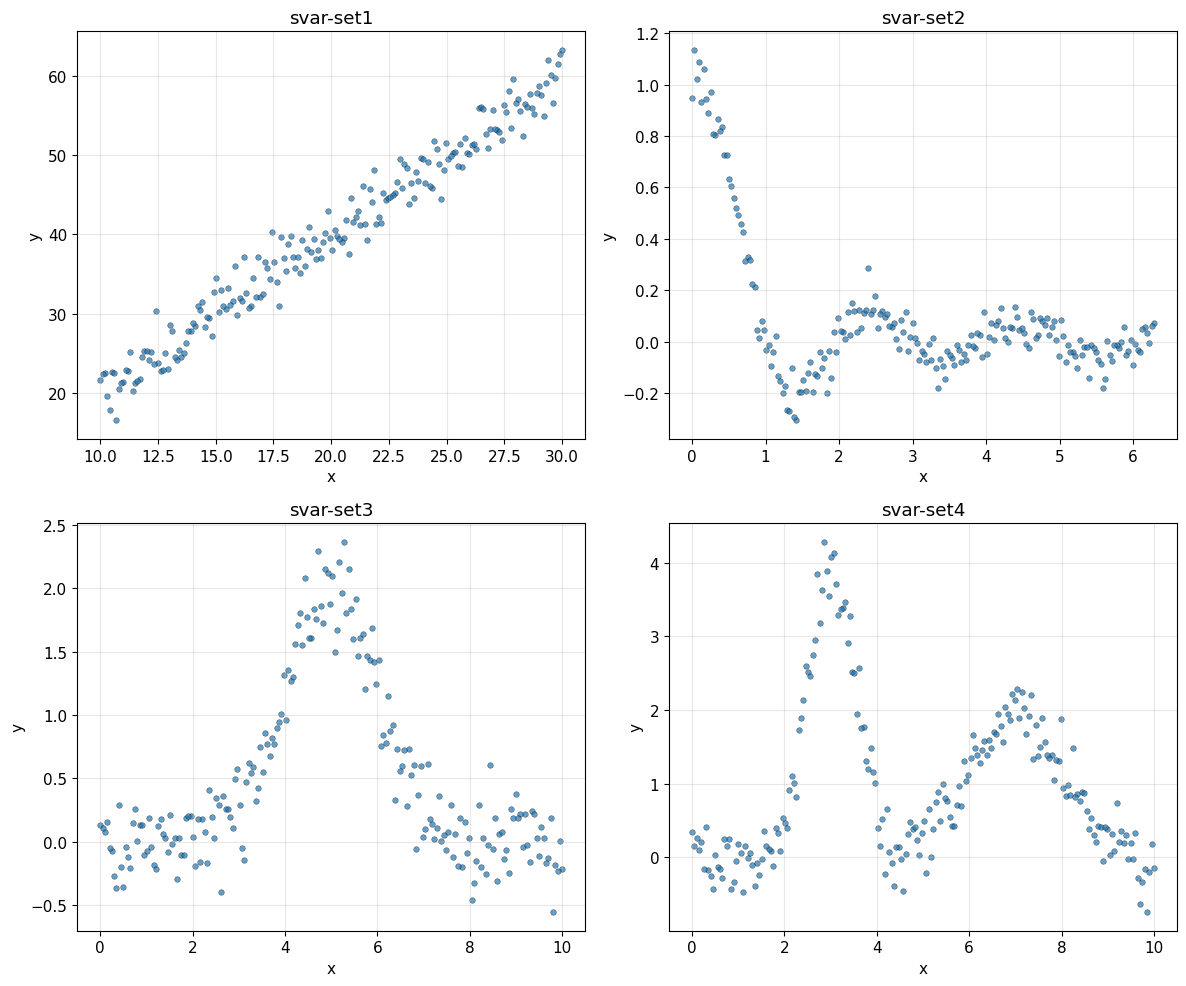

In [4]:
svar_names = ["svar-set1.csv", "svar-set2.csv", "svar-set3.csv", "svar-set4.csv"]
svar_data = {}

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
for idx, name in enumerate(svar_names):
    X, y = load_dataset(DATA_DIR / name)
    svar_data[name] = (X, y)
    ax = axes[idx // 2, idx % 2]
    ax.scatter(X, y, s=16, alpha=0.7, edgecolors='k', linewidths=0.3)
    ax.set_xlabel("x"); ax.set_ylabel("y")
    ax.set_title(name.replace('.csv', ''))
    ax.grid(alpha=0.3)
    print(f"{name}: n={len(y)}, x range=[{X.min():.2f}, {X.max():.2f}], y range=[{y.min():.2f}, {y.max():.2f}]")
plt.tight_layout(); plt.show()

**Observations (Problem 1.1):**
- **svar-set1** appears nearly linear with moderate noise.
- **svar-set2** shows a clear non-linear (polynomial) trend.
- **svar-set3** exhibits higher-degree curvature or more complex structure.
- **svar-set4** looks roughly linear but with heavier noise / potential outliers.

Problem 1.2: OLS — Normal Equations vs Gradient Descent

svar-set1.csv:
  NE  -> theta = [0.2612, 1.9861], RMSE = 2.057321
  GD  -> theta = [39.9828, 11.5241], RMSE = 2.057321
  GD converged in 563 epochs

svar-set2.csv:
  NE  -> theta = [0.3324, -0.0777], RMSE = 0.244075
  GD  -> theta = [0.0881, -0.1412], RMSE = 0.244075
  GD converged in 290 epochs

svar-set3.csv:
  NE  -> theta = [0.5010, -0.0023], RMSE = 0.706197
  GD  -> theta = [0.4888, -0.0068], RMSE = 0.706197
  GD converged in 343 epochs

svar-set4.csv:
  NE  -> theta = [0.9978, -0.0054], RMSE = 1.095814
  GD  -> theta = [0.9704, -0.0156], RMSE = 1.095814
  GD converged in 377 epochs


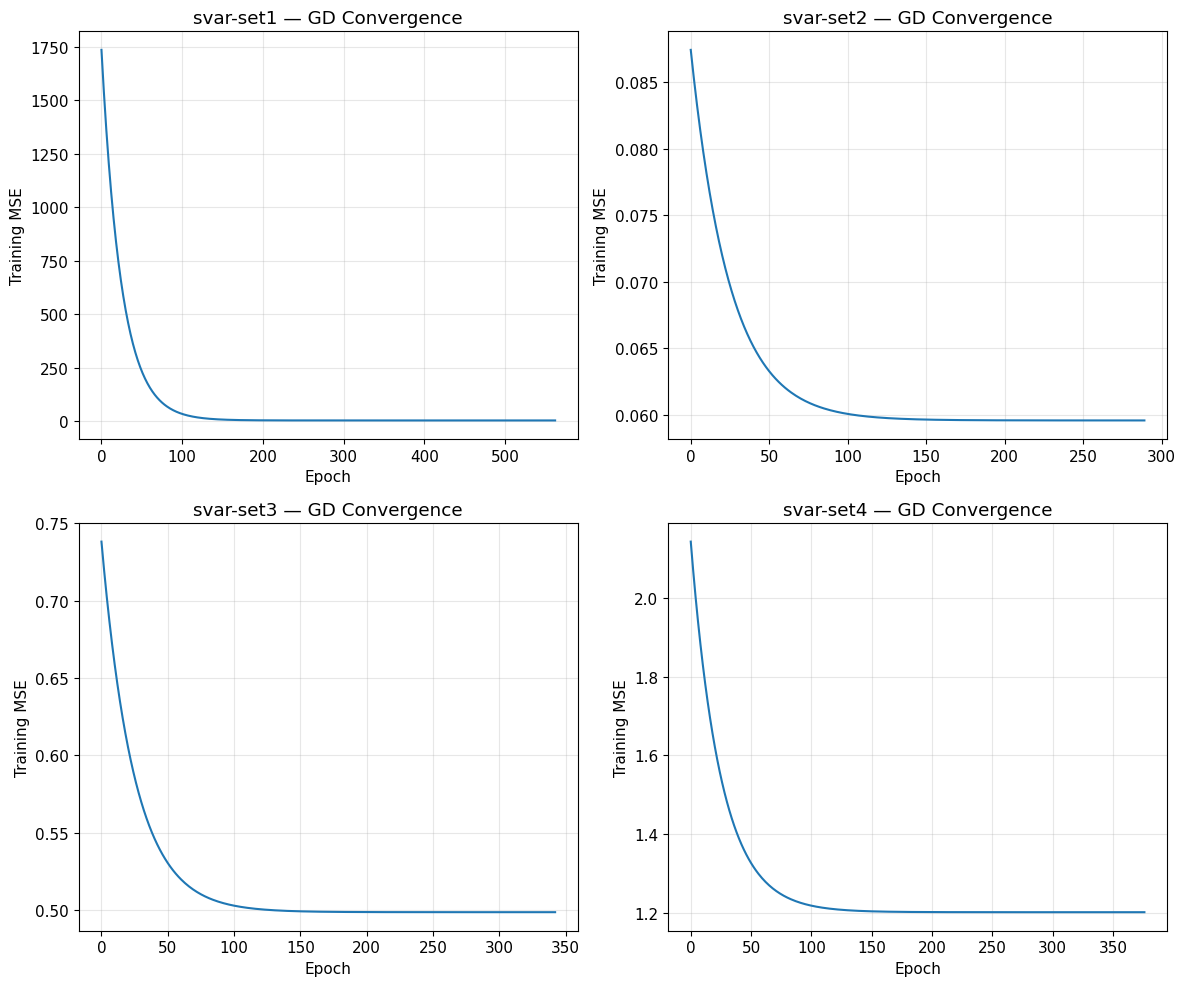

In [5]:
print("=" * 80)
print("Problem 1.2: OLS — Normal Equations vs Gradient Descent")
print("=" * 80)

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

for idx, name in enumerate(svar_names):
    X, y = svar_data[name]

    # ── Normal Equations (raw features + bias) ──
    X_b = add_bias(X)
    theta_ne = ols_normal_eq(X_b, y)
    rmse_ne = rmse(y, X_b @ theta_ne)

    # ── Gradient Descent (standardize first for stability) ──
    X_std = standardize(X)
    X_std_b = add_bias(X_std)
    theta_gd, mse_hist = ols_gradient_descent(X_std_b, y, lr=0.01, epochs=5000)
    rmse_gd = rmse(y, X_std_b @ theta_gd)

    print(f"\n{name}:")
    print(f"  NE  -> theta = [{theta_ne[0]:.4f}, {theta_ne[1]:.4f}], RMSE = {rmse_ne:.6f}")
    print(f"  GD  -> theta = [{theta_gd[0]:.4f}, {theta_gd[1]:.4f}], RMSE = {rmse_gd:.6f}")
    print(f"  GD converged in {len(mse_hist)} epochs")

    ax = axes[idx // 2, idx % 2]
    ax.plot(mse_hist, linewidth=1.5)
    ax.set_xlabel("Epoch"); ax.set_ylabel("Training MSE")
    ax.set_title(f"{name.replace('.csv', '')} — GD Convergence")
    ax.grid(alpha=0.3)

plt.tight_layout(); plt.show()

Problem 1.3: 10-Fold CV — Linear OLS
  [Linear svar-set1.csv]  RMSE = 2.0513 ± 0.3494  |  MAE = 1.6593 ± 0.3029  |  R² = 0.9661 ± 0.0107
  [Linear svar-set2.csv]  RMSE = 0.2422 ± 0.0509  |  MAE = 0.1755 ± 0.0380  |  R² = 0.0589 ± 0.2588
  [Linear svar-set3.csv]  RMSE = 0.7093 ± 0.0772  |  MAE = 0.5879 ± 0.0592  |  R² = -0.0688 ± 0.0971
  [Linear svar-set4.csv]  RMSE = 1.0863 ± 0.2106  |  MAE = 0.8958 ± 0.1571  |  R² = -0.0636 ± 0.0896


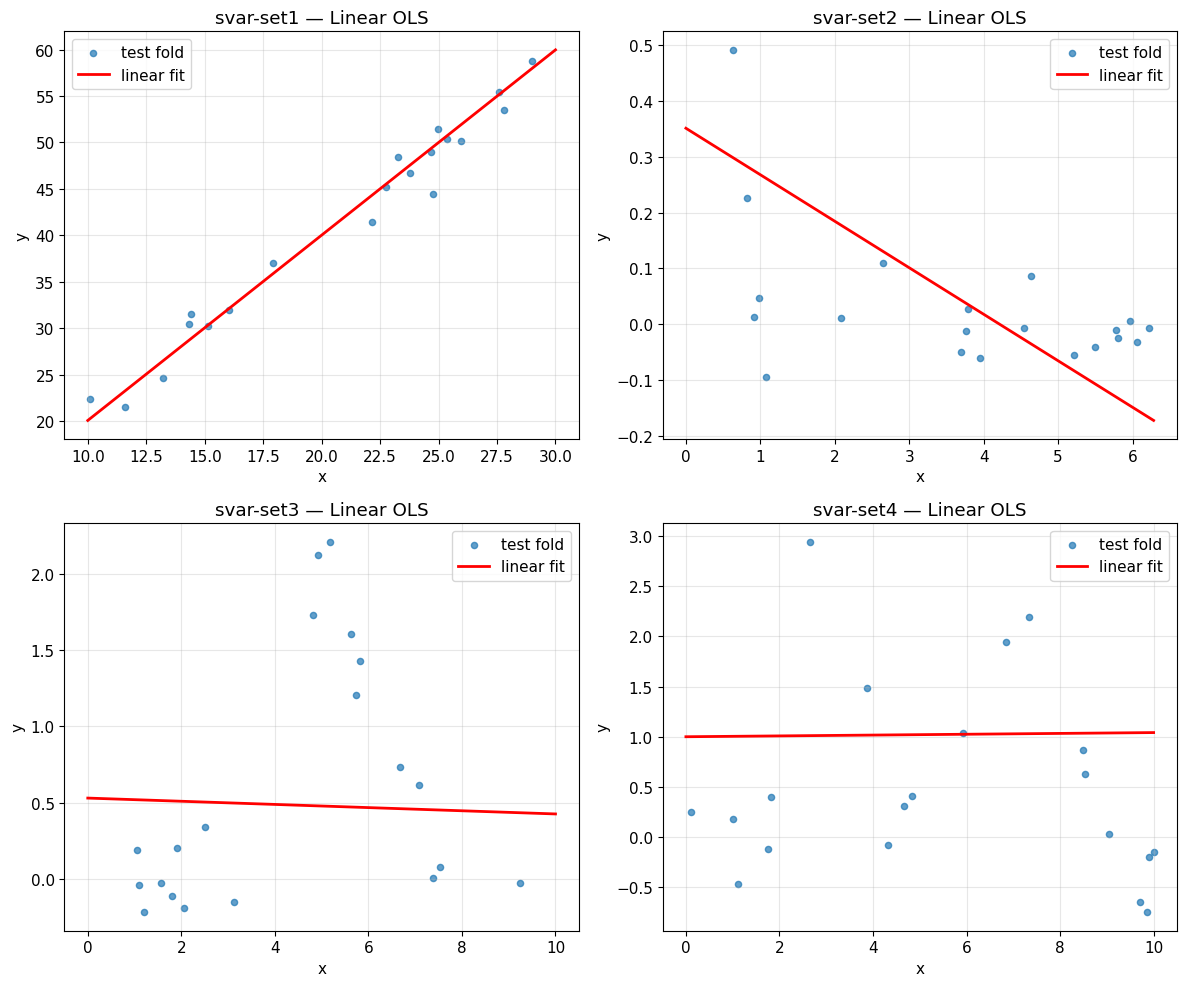

In [6]:
print("=" * 80)
print("Problem 1.3: 10-Fold CV — Linear OLS")
print("=" * 80)

def linear_ols_fp(X_tr, y_tr, X_te):
    X_tr_s, X_te_s = standardize(X_tr, X_te)
    theta = ols_normal_eq(add_bias(X_tr_s), y_tr)
    return add_bias(X_te_s) @ theta

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

for idx, name in enumerate(svar_names):
    X, y = svar_data[name]
    results = cross_validate(linear_ols_fp, X, y)
    report_cv(results, f"Linear {name}")

    # Overlay fitted line on first held-out fold
    kf = KFold(n_splits=10, shuffle=True, random_state=SEED)
    tr_idx, te_idx = next(iter(kf.split(X)))
    X_tr, X_te, y_tr, y_te = X[tr_idx], X[te_idx], y[tr_idx], y[te_idx]

    X_tr_s, X_te_s = standardize(X_tr, X_te)
    theta = ols_normal_eq(add_bias(X_tr_s), y_tr)

    # For plotting: transform a fine grid through the same standardization
    mu, sig = X_tr.mean(axis=0), X_tr.std(axis=0)
    sig[sig < 1e-10] = 1.0
    xs = np.linspace(X.min(), X.max(), 300).reshape(-1, 1)
    xs_s = (xs - mu) / sig
    ys = add_bias(xs_s) @ theta

    ax = axes[idx // 2, idx % 2]
    ax.scatter(X_te, y_te, s=20, alpha=0.7, label="test fold")
    ax.plot(xs, ys, 'r-', lw=2, label="linear fit")
    ax.set_xlabel("x"); ax.set_ylabel("y")
    ax.set_title(f"{name.replace('.csv', '')} — Linear OLS")
    ax.legend(); ax.grid(alpha=0.3)

plt.tight_layout(); plt.show()

Problem 1.4: Polynomial Degree Selection (d = 2..10)
  svar-set1.csv: best degree = 6, CV-RMSE = 2.0526
  svar-set2.csv: best degree = 10, CV-RMSE = 0.0539
  svar-set3.csv: best degree = 10, CV-RMSE = 0.2139
  svar-set4.csv: best degree = 10, CV-RMSE = 0.4537


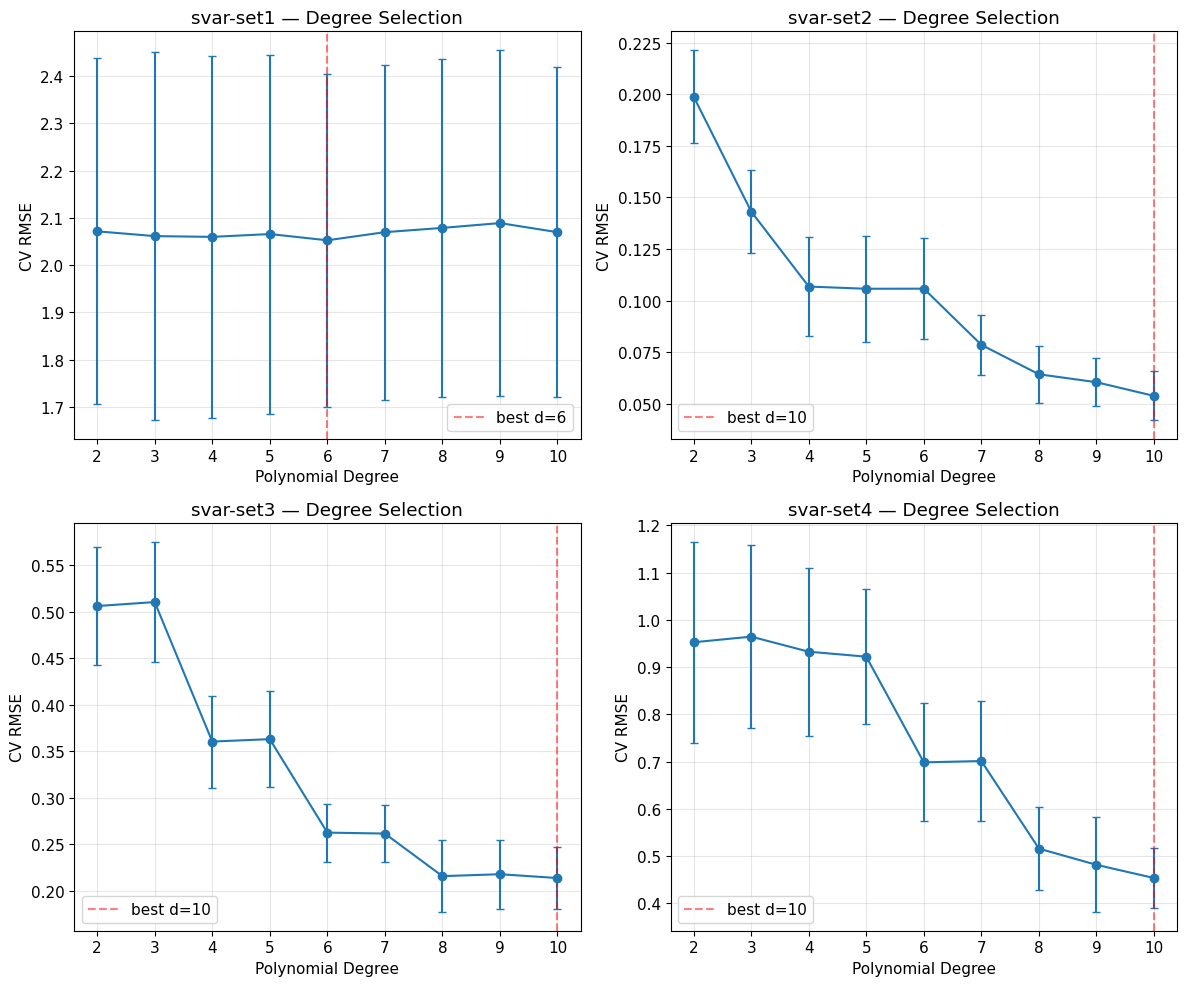

In [7]:
print("=" * 80)
print("Problem 1.4: Polynomial Degree Selection (d = 2..10)")
print("=" * 80)

degrees = list(range(2, 11))
best_degrees = {}

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

for idx, name in enumerate(svar_names):
    X, y = svar_data[name]
    cv_means, cv_stds = [], []

    for d in degrees:
        def _poly_fp(X_tr, y_tr, X_te, _d=d):
            Xtr_p = poly_features_1d(X_tr, _d)
            Xte_p = poly_features_1d(X_te, _d)
            Xtr_s, Xte_s = standardize(Xtr_p, Xte_p)
            theta = ols_normal_eq(add_bias(Xtr_s), y_tr)
            return add_bias(Xte_s) @ theta
        res = cross_validate(_poly_fp, X, y)
        cv_means.append(res['rmse'].mean())
        cv_stds.append(res['rmse'].std())

    best_d = degrees[int(np.argmin(cv_means))]
    best_degrees[name] = best_d
    print(f"  {name}: best degree = {best_d}, CV-RMSE = {min(cv_means):.4f}")

    ax = axes[idx // 2, idx % 2]
    ax.errorbar(degrees, cv_means, yerr=cv_stds, marker='o', capsize=3)
    ax.axvline(best_d, color='r', ls='--', alpha=0.5, label=f"best d={best_d}")
    ax.set_xlabel("Polynomial Degree"); ax.set_ylabel("CV RMSE")
    ax.set_title(f"{name.replace('.csv', '')} — Degree Selection")
    ax.legend(); ax.grid(alpha=0.3)

plt.tight_layout(); plt.show()

Problem 1.5: Data Ablation Study


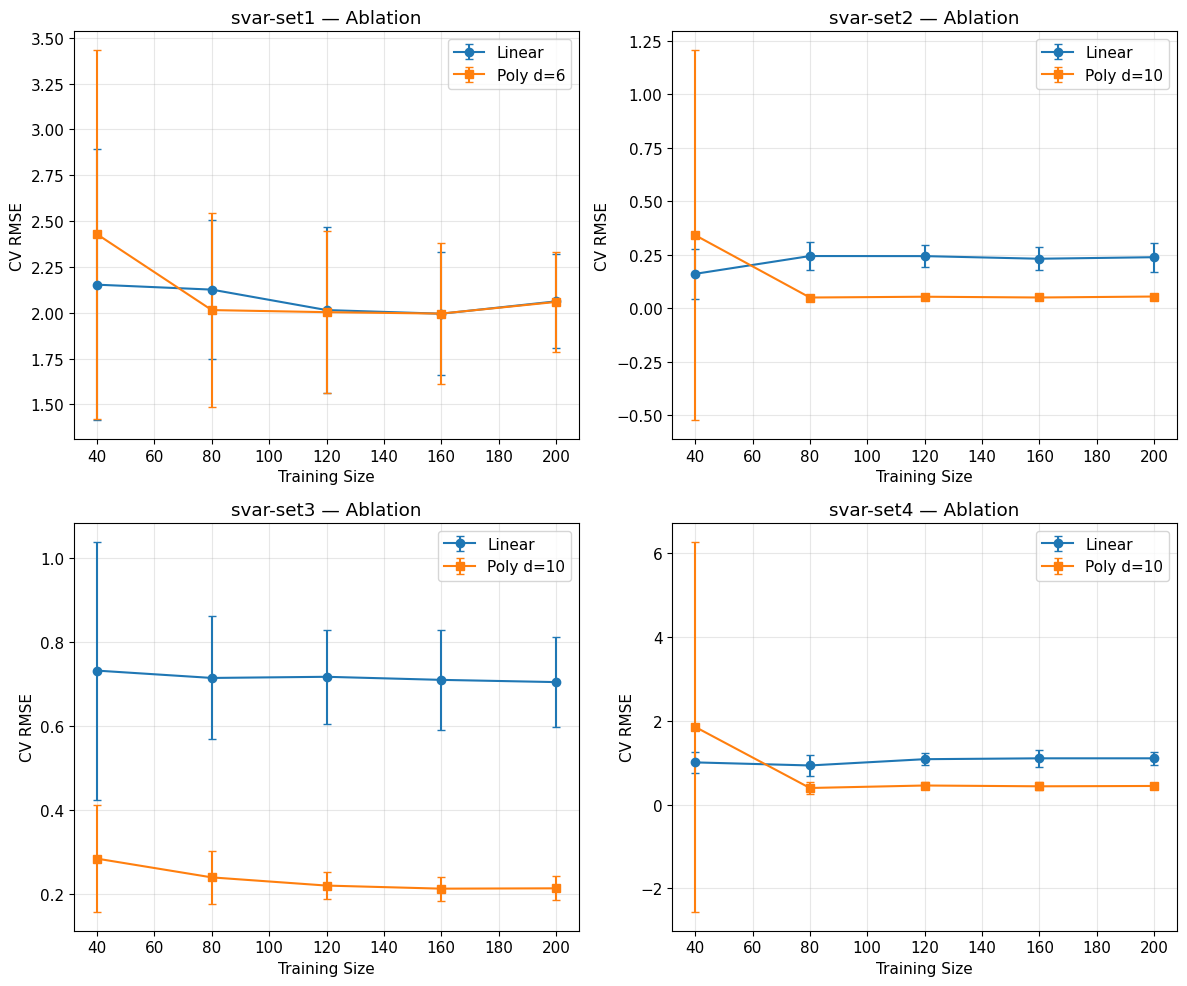

In [8]:
print("=" * 80)
print("Problem 1.5: Data Ablation Study")
print("=" * 80)

fractions = [0.2, 0.4, 0.6, 0.8, 1.0]

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

for idx, name in enumerate(svar_names):
    X, y = svar_data[name]
    n_total = len(y)
    best_d = best_degrees[name]

    lin_means, lin_stds = [], []
    poly_means, poly_stds = [], []

    for frac in fractions:
        n_sub = max(int(n_total * frac), 20)
        rng = np.random.RandomState(SEED)
        sub_idx = rng.choice(n_total, n_sub, replace=False)
        X_sub, y_sub = X[sub_idx], y[sub_idx]

        # Linear
        k_cv = min(10, n_sub)
        res_lin = cross_validate(linear_ols_fp, X_sub, y_sub, k=k_cv)
        lin_means.append(res_lin['rmse'].mean())
        lin_stds.append(res_lin['rmse'].std())

        # Best polynomial
        def _poly_fp(X_tr, y_tr, X_te, _d=best_d):
            Xtr_p = poly_features_1d(X_tr, _d)
            Xte_p = poly_features_1d(X_te, _d)
            Xtr_s, Xte_s = standardize(Xtr_p, Xte_p)
            theta = ols_normal_eq(add_bias(Xtr_s), y_tr)
            return add_bias(Xte_s) @ theta

        res_poly = cross_validate(_poly_fp, X_sub, y_sub, k=k_cv)
        poly_means.append(res_poly['rmse'].mean())
        poly_stds.append(res_poly['rmse'].std())

    sizes = [max(int(n_total * f), 20) for f in fractions]
    ax = axes[idx // 2, idx % 2]
    ax.errorbar(sizes, lin_means, yerr=lin_stds, marker='o', capsize=3, label="Linear")
    ax.errorbar(sizes, poly_means, yerr=poly_stds, marker='s', capsize=3, label=f"Poly d={best_d}")
    ax.set_xlabel("Training Size"); ax.set_ylabel("CV RMSE")
    ax.set_title(f"{name.replace('.csv', '')} — Ablation")
    ax.legend(); ax.grid(alpha=0.3)

plt.tight_layout(); plt.show()

**Bias-Variance Discussion (Problem 1.5):**
- With fewer training points the *variance* is high (wide error bars) and both models are noisy.
- The polynomial model shows a larger decrease in RMSE as data grows, indicating it has
  lower bias when the true relationship is non-linear but needs more data to control variance.
- The linear model is stable across sizes (low variance) but cannot capture curvature (high bias
  on non-linear datasets).
- This illustrates the **bias-variance tradeoff**: higher capacity (polynomial) reduces bias but
  increases variance; more data helps tame variance.

In [9]:
print("=" * 80)
print("Problem 1.6: Comparison with scikit-learn")
print("=" * 80)

kf_fixed = KFold(n_splits=10, shuffle=True, random_state=SEED)

for name in svar_names:
    X, y = svar_data[name]
    best_d = best_degrees[name]

    # ─── From-scratch ───
    res_lin = cross_validate(linear_ols_fp, X, y)

    def _poly_best(X_tr, y_tr, X_te, _d=best_d):
        Xtr_p = poly_features_1d(X_tr, _d)
        Xte_p = poly_features_1d(X_te, _d)
        Xtr_s, Xte_s = standardize(Xtr_p, Xte_p)
        theta = ols_normal_eq(add_bias(Xtr_s), y_tr)
        return add_bias(Xte_s) @ theta
    res_poly = cross_validate(_poly_best, X, y)

    # ─── sklearn ───
    sk_lin_rmse, sk_poly_rmse = [], []
    for tr_i, te_i in kf_fixed.split(X):
        # Linear
        pipe_lin = SkPipeline([("sc", SkScaler()), ("lr", SkLinReg())])
        pipe_lin.fit(X[tr_i], y[tr_i])
        sk_lin_rmse.append(rmse(y[te_i], pipe_lin.predict(X[te_i])))

        # Polynomial (poly THEN scale to match our pipeline order)
        pipe_poly = SkPipeline([
            ("poly", SkPoly(degree=best_d, include_bias=False)),
            ("sc", SkScaler()),
            ("lr", SkLinReg())
        ])
        pipe_poly.fit(X[tr_i], y[tr_i])
        sk_poly_rmse.append(rmse(y[te_i], pipe_poly.predict(X[te_i])))

    diff_lin = abs(res_lin['rmse'].mean() - np.mean(sk_lin_rmse))
    diff_poly = abs(res_poly['rmse'].mean() - np.mean(sk_poly_rmse))

    print(f"\n{name} (best d={best_d}):")
    print(f"  Linear  — scratch: {res_lin['rmse'].mean():.6f}, sklearn: {np.mean(sk_lin_rmse):.6f}, diff: {diff_lin:.2e}")
    print(f"  Poly-{best_d}  — scratch: {res_poly['rmse'].mean():.6f}, sklearn: {np.mean(sk_poly_rmse):.6f}, diff: {diff_poly:.2e}")

print("\n(Differences should be near machine precision ~1e-10 to 1e-6.)")
print("Note: Both pipelines use poly -> standardize -> OLS ordering for fair comparison.")

Problem 1.6: Comparison with scikit-learn

svar-set1.csv (best d=6):
  Linear  — scratch: 2.051347, sklearn: 2.051347, diff: 4.44e-16
  Poly-6  — scratch: 2.052599, sklearn: 2.052599, diff: 4.02e-08

svar-set2.csv (best d=10):
  Linear  — scratch: 0.242244, sklearn: 0.242244, diff: 2.78e-17
  Poly-10  — scratch: 0.053876, sklearn: 0.053864, diff: 1.17e-05



svar-set3.csv (best d=10):
  Linear  — scratch: 0.709271, sklearn: 0.709271, diff: 0.00e+00
  Poly-10  — scratch: 0.213865, sklearn: 0.213858, diff: 6.91e-06

svar-set4.csv (best d=10):
  Linear  — scratch: 1.086300, sklearn: 1.086300, diff: 0.00e+00
  Poly-10  — scratch: 0.453726, sklearn: 0.453871, diff: 1.44e-04

(Differences should be near machine precision ~1e-10 to 1e-6.)
Note: Both pipelines use poly -> standardize -> OLS ordering for fair comparison.


---
## Section 2 — Multivariate Regression (Feature Mapping & Solvers)

In [10]:
print("=" * 80)
print("Problem 2.1: Load Multivariate Datasets")
print("=" * 80)

mvar_names = ["mvar-set1.csv", "mvar-set2.csv", "mvar-set3.csv", "mvar-set4.csv"]
mvar_data = {}

for name in mvar_names:
    X, y = load_dataset(DATA_DIR / name)
    mvar_data[name] = (X, y)
    print(f"\n{name}: n={X.shape[0]}, d={X.shape[1]}")
    print(f"  X means:  {np.round(X.mean(axis=0), 4)}")
    print(f"  X vars:   {np.round(X.var(axis=0), 4)}")
    print(f"  y mean={y.mean():.4f}, y std={y.std():.4f}")
    if X.shape[1] <= 5:
        corr = np.corrcoef(X.T)
        print(f"  Feature correlation matrix:\n{np.round(corr, 3)}")

Problem 2.1: Load Multivariate Datasets

mvar-set1.csv: n=2500, d=2
  X means:  [-0. -0.]
  X vars:   [1.3878 1.3878]
  y mean=0.9959, y std=1.7324
  Feature correlation matrix:
[[1. 0.]
 [0. 1.]]

mvar-set2.csv: n=2500, d=2
  X means:  [-0. -0.]
  X vars:   [1.3878 1.3878]
  y mean=0.0009, y std=0.1603
  Feature correlation matrix:
[[1. 0.]
 [0. 1.]]

mvar-set3.csv: n=100000, d=5
  X means:  [ 0.0017 -0.0002 -0.     -0.0007  0.0001]
  X vars:   [1.6694 1.6711 1.6732 1.6705 1.6693]
  y mean=1.0006, y std=3.4548
  Feature correlation matrix:
[[ 1.     0.    -0.001 -0.001  0.001]
 [ 0.     1.    -0.     0.001  0.   ]
 [-0.001 -0.     1.    -0.001 -0.   ]
 [-0.001  0.001 -0.001  1.    -0.   ]
 [ 0.001  0.    -0.    -0.     1.   ]]



mvar-set4.csv: n=100000, d=5
  X means:  [ 0.001   0.0002 -0.0002 -0.0002 -0.0003]
  X vars:   [1.6713 1.6689 1.6703 1.6704 1.6703]
  y mean=0.0101, y std=0.0647
  Feature correlation matrix:
[[ 1.     0.     0.     0.001 -0.   ]
 [ 0.     1.     0.001  0.     0.   ]
 [ 0.     0.001  1.    -0.    -0.   ]
 [ 0.001  0.    -0.     1.     0.001]
 [-0.     0.    -0.     0.001  1.   ]]


In [11]:
print("=" * 80)
print("Problem 2.2: Feature Maps & Subsampling")
print("=" * 80)

# Subsample large datasets to 5 000 for primal methods
mvar_work = {}
for name in mvar_names:
    X, y = mvar_data[name]
    if X.shape[0] > 10_000:
        rng = np.random.RandomState(SEED)
        idx = rng.choice(X.shape[0], 5000, replace=False)
        X, y = X[idx], y[idx]
        print(f"  {name}: subsampled to {X.shape[0]} rows")
    mvar_work[name] = (X, y)

print()
for name in mvar_names:
    X, y = mvar_work[name]
    Xp = pairwise_product_features(X)
    Xm = poly_features_multi(X, 3)
    print(f"  {name}: original d={X.shape[1]}, pairwise={Xp.shape[1]}, poly3={Xm.shape[1]}")

Problem 2.2: Feature Maps & Subsampling
  mvar-set3.csv: subsampled to 5000 rows
  mvar-set4.csv: subsampled to 5000 rows

  mvar-set1.csv: original d=2, pairwise=5, poly3=9
  mvar-set2.csv: original d=2, pairwise=5, poly3=9
  mvar-set3.csv: original d=5, pairwise=20, poly3=55
  mvar-set4.csv: original d=5, pairwise=20, poly3=55


In [12]:
print("=" * 80)
print("Problem 2.3: OLS — Normal Equations (Tikhonov) vs Gradient Descent")
print("=" * 80)

rows_2_3 = []

for name in mvar_names:
    X, y = mvar_work[name]

    for feat_label, feat_fn in [("pairwise", pairwise_product_features),
                                ("poly-3", lambda X: poly_features_multi(X, 3))]:

        # ── Normal Equations + Tikhonov (lambda=1e-8) ──
        def _ne_fp(X_tr, y_tr, X_te, _ff=feat_fn):
            Xtr_f, Xte_f = _ff(X_tr), _ff(X_te)
            Xtr_f, Xte_f = drop_low_variance(Xtr_f, Xte_f)
            Xtr_s, Xte_s = standardize(Xtr_f, Xte_f)
            theta = ols_tikhonov(add_bias(Xtr_s), y_tr, lam=1e-8)
            return add_bias(Xte_s) @ theta

        t0 = time.time()
        res_ne = cross_validate(_ne_fp, X, y)
        t_ne = time.time() - t0

        # ── Gradient Descent ──
        def _gd_fp(X_tr, y_tr, X_te, _ff=feat_fn):
            Xtr_f, Xte_f = _ff(X_tr), _ff(X_te)
            Xtr_f, Xte_f = drop_low_variance(Xtr_f, Xte_f)
            Xtr_s, Xte_s = standardize(Xtr_f, Xte_f)
            theta, _ = ols_gradient_descent(add_bias(Xtr_s), y_tr, lr=0.001, epochs=10000)
            return add_bias(Xte_s) @ theta

        t0 = time.time()
        res_gd = cross_validate(_gd_fp, X, y)
        t_gd = time.time() - t0

        rows_2_3.append((name, feat_label, "NE+Tikh", res_ne['rmse'].mean(), res_ne['rmse'].std(), t_ne))
        rows_2_3.append((name, feat_label, "GD",      res_gd['rmse'].mean(), res_gd['rmse'].std(), t_gd))

# Print table
print(f"\n{'Dataset':>15s} | {'Features':>10s} | {'Solver':>10s} | {'RMSE (mean±std)':>22s} | {'Time (s)':>8s}")
print("-" * 78)
for ds, ft, sl, m, s, t in rows_2_3:
    print(f"{ds:>15s} | {ft:>10s} | {sl:>10s} | {m:>8.4f} ± {s:<8.4f} | {t:>8.2f}")

print("\nNormal equations is typically faster and more accurate; GD may not fully converge")
print("on high-dimensional feature maps within 10 000 epochs.")

Problem 2.3: OLS — Normal Equations (Tikhonov) vs Gradient Descent



        Dataset |   Features |     Solver |        RMSE (mean±std) | Time (s)
------------------------------------------------------------------------------
  mvar-set1.csv |   pairwise |    NE+Tikh |   0.5092 ± 0.0187   |     0.01
  mvar-set1.csv |   pairwise |         GD |   0.5092 ± 0.0187   |     2.30
  mvar-set1.csv |     poly-3 |    NE+Tikh |   0.5099 ± 0.0182   |     0.01
  mvar-set1.csv |     poly-3 |         GD |   0.5150 ± 0.0196   |     8.60
  mvar-set2.csv |   pairwise |    NE+Tikh |   0.1411 ± 0.0064   |     0.00
  mvar-set2.csv |   pairwise |         GD |   0.1411 ± 0.0064   |     1.50
  mvar-set2.csv |     poly-3 |    NE+Tikh |   0.1019 ± 0.0043   |     0.00
  mvar-set2.csv |     poly-3 |         GD |   0.1042 ± 0.0050   |     8.93
  mvar-set3.csv |   pairwise |    NE+Tikh |   0.5054 ± 0.0147   |     0.01
  mvar-set3.csv |   pairwise |         GD |   0.5054 ± 0.0147   |     4.68
  mvar-set3.csv |     poly-3 |    NE+Tikh |   0.5079 ± 0.0144   |     0.04
  mvar-set3.csv |

Problem 2.4: Ridge Regression — Lambda Tuning


  mvar-set1.csv: best lambda = 7.88e-01, CV-RMSE = 0.5099
  mvar-set2.csv: best lambda = 1.61e+00, CV-RMSE = 0.1019


  mvar-set3.csv: best lambda = 4.52e-02, CV-RMSE = 0.5079


  mvar-set4.csv: best lambda = 4.89e+02, CV-RMSE = 0.0626


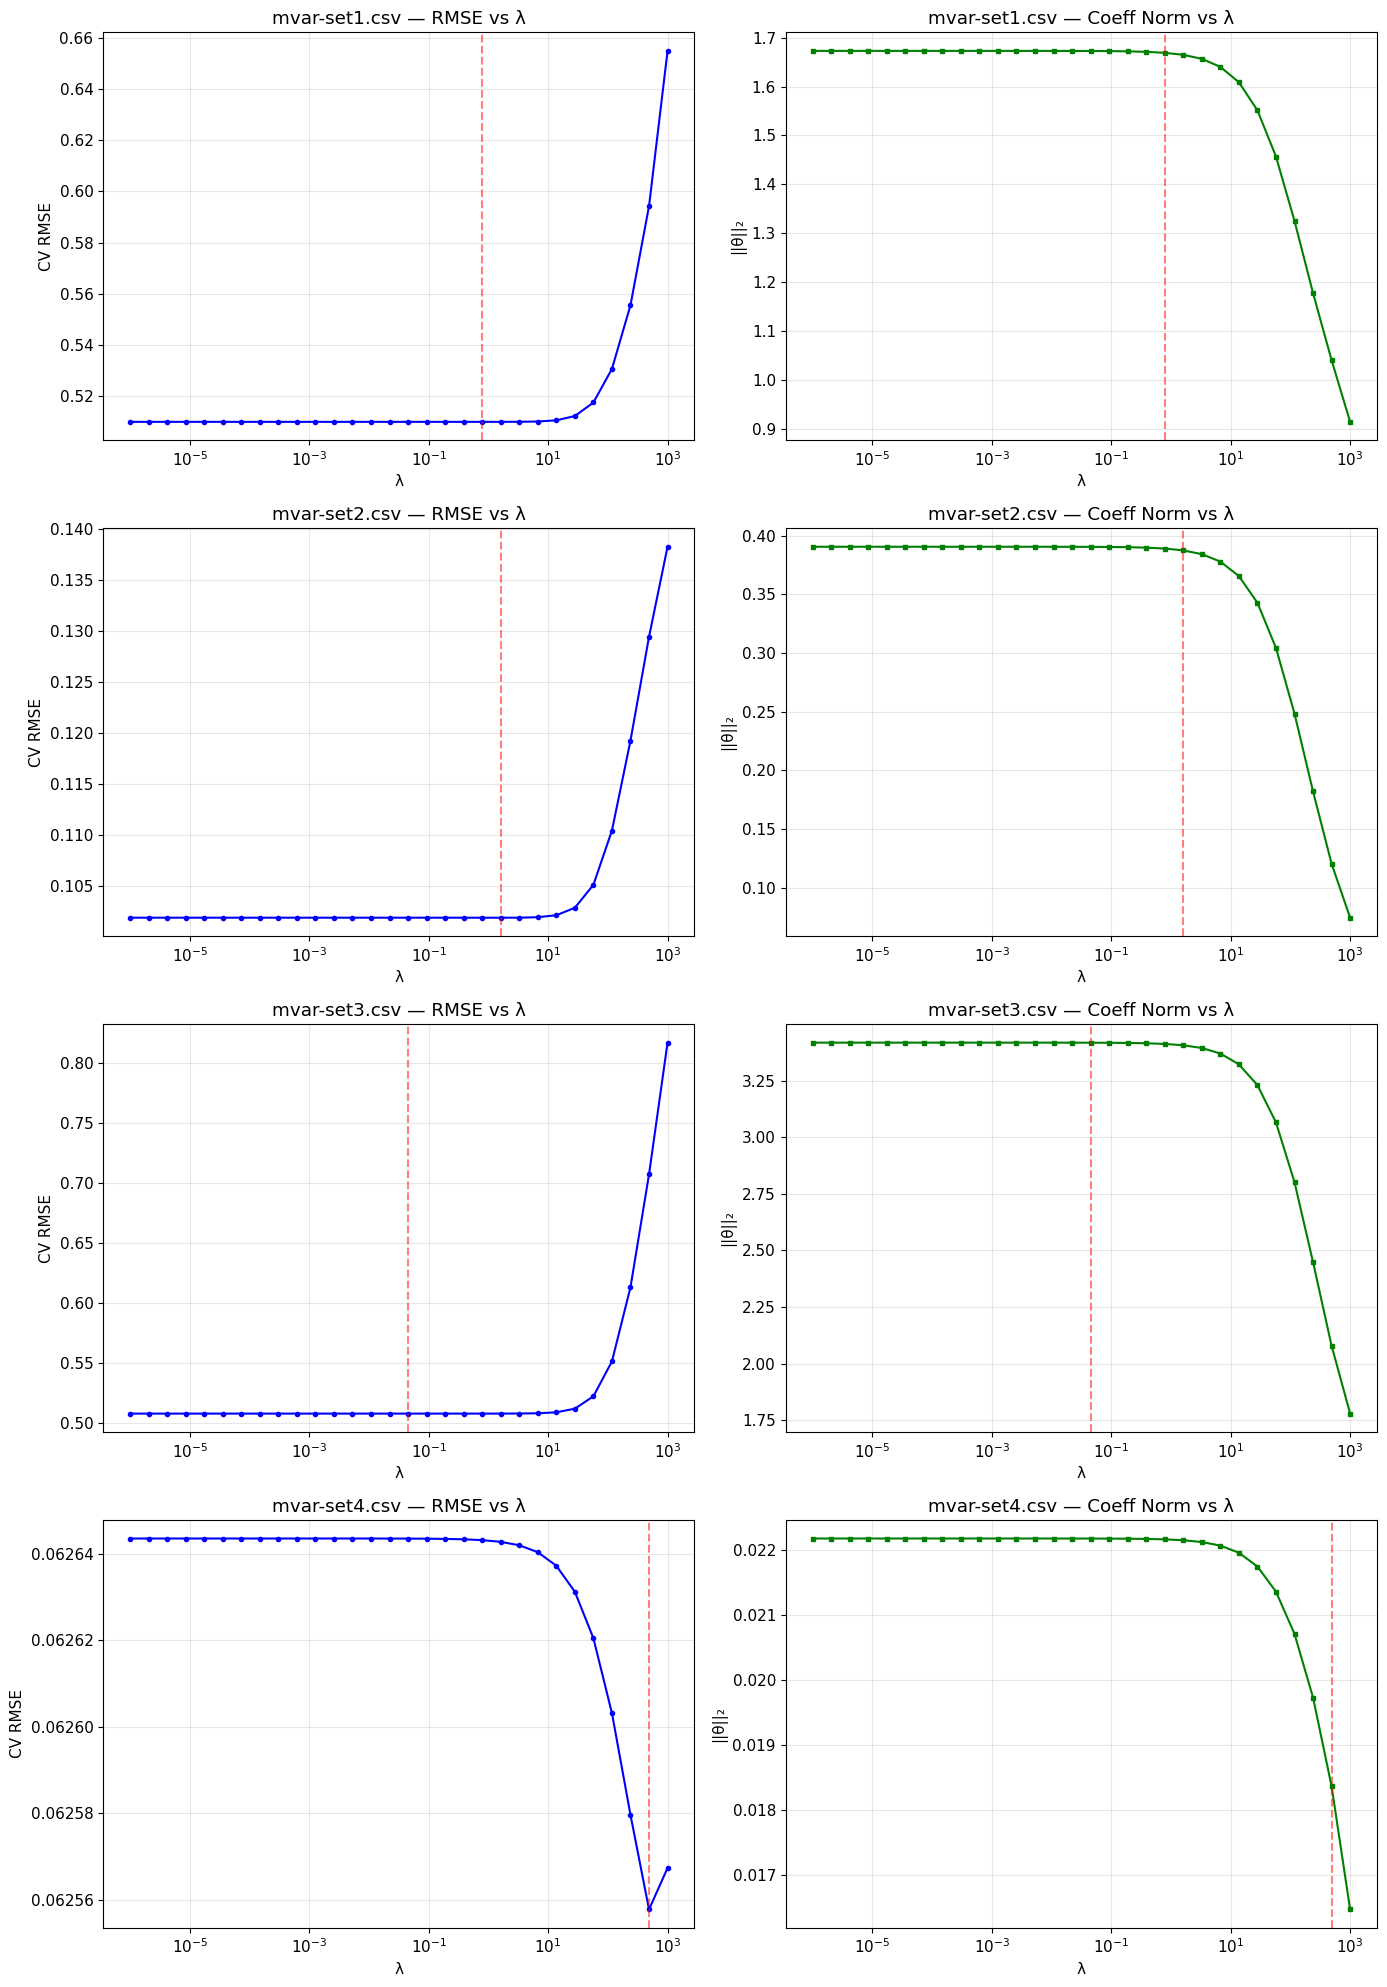

In [13]:
print("=" * 80)
print("Problem 2.4: Ridge Regression — Lambda Tuning")
print("=" * 80)

lambdas = np.logspace(-6, 3, 30)
ridge_best_lam = {}

fig, axes = plt.subplots(4, 2, figsize=(14, 20))

for idx, name in enumerate(mvar_names):
    X, y = mvar_work[name]
    rmse_means, theta_norms = [], []

    for lam in lambdas:
        def _ridge_fp(X_tr, y_tr, X_te, _lam=lam):
            Xtr_p = poly_features_multi(X_tr, 3)
            Xte_p = poly_features_multi(X_te, 3)
            Xtr_p, Xte_p = drop_low_variance(Xtr_p, Xte_p)
            Xtr_s, Xte_s = standardize(Xtr_p, Xte_p)
            theta = ridge_regression(add_bias(Xtr_s), y_tr, _lam)
            return add_bias(Xte_s) @ theta

        res = cross_validate(_ridge_fp, X, y)
        rmse_means.append(res['rmse'].mean())

        # Coefficient norm on full data
        Xp = poly_features_multi(X, 3)
        var = Xp.var(axis=0); Xp = Xp[:, var >= 1e-6]
        Xs = standardize(Xp)
        theta_full = ridge_regression(add_bias(Xs), y, lam)
        theta_norms.append(np.linalg.norm(theta_full[1:]))

    best_lam = lambdas[int(np.argmin(rmse_means))]
    ridge_best_lam[name] = best_lam
    print(f"  {name}: best lambda = {best_lam:.2e}, CV-RMSE = {min(rmse_means):.4f}")

    axes[idx, 0].semilogx(lambdas, rmse_means, 'b-o', ms=3)
    axes[idx, 0].axvline(best_lam, color='r', ls='--', alpha=0.5)
    axes[idx, 0].set_xlabel("λ"); axes[idx, 0].set_ylabel("CV RMSE")
    axes[idx, 0].set_title(f"{name} — RMSE vs λ"); axes[idx, 0].grid(alpha=0.3)

    axes[idx, 1].semilogx(lambdas, theta_norms, 'g-s', ms=3)
    axes[idx, 1].axvline(best_lam, color='r', ls='--', alpha=0.5)
    axes[idx, 1].set_xlabel("λ"); axes[idx, 1].set_ylabel("||θ||₂")
    axes[idx, 1].set_title(f"{name} — Coeff Norm vs λ"); axes[idx, 1].grid(alpha=0.3)

plt.tight_layout(); plt.show()

**Discussion (Problem 2.4 — Ridge):**
- As **λ increases**, the coefficient norm **shrinks** toward zero (explicit shrinkage),
  and the condition number of *(XᵀX + λI)* improves (better numerical stability).
- Very small λ ≈ OLS: low bias, potentially high variance (overfitting, especially
  with many polynomial features).
- Very large λ: underfitting (high bias), coefficients are over-penalized.
- The optimal λ strikes a **bias-variance balance**: enough regularization to prevent
  overfitting the high-dimensional feature map, but not so much that the model loses
  predictive power.

In [14]:
print("=" * 80)
print("Problem 2.5: Robust Regression — Huber Loss")
print("=" * 80)

def _ols_multi_fp(X_tr, y_tr, X_te):
    Xtr_p = poly_features_multi(X_tr, 3)
    Xte_p = poly_features_multi(X_te, 3)
    Xtr_p, Xte_p = drop_low_variance(Xtr_p, Xte_p)
    Xtr_s, Xte_s = standardize(Xtr_p, Xte_p)
    theta = ols_tikhonov(add_bias(Xtr_s), y_tr, lam=1e-8)
    return add_bias(Xte_s) @ theta

def _huber_multi_fp(X_tr, y_tr, X_te, delta=1.35):
    Xtr_p = poly_features_multi(X_tr, 3)
    Xte_p = poly_features_multi(X_te, 3)
    Xtr_p, Xte_p = drop_low_variance(Xtr_p, Xte_p)
    Xtr_s, Xte_s = standardize(Xtr_p, Xte_p)
    theta = huber_regression(add_bias(Xtr_s), y_tr, delta=delta)
    return add_bias(Xte_s) @ theta

print(f"\n{'Dataset':>15s} | {'Model':>8s} | {'RMSE':>18s} | {'MAE':>18s} | {'R²':>18s}")
print("-" * 90)

for name in mvar_names:
    X, y = mvar_work[name]
    res_ols = cross_validate(_ols_multi_fp, X, y)
    res_hub = cross_validate(_huber_multi_fp, X, y)

    for label, res in [("OLS", res_ols), ("Huber", res_hub)]:
        print(f"{name:>15s} | {label:>8s} | "
              f"{res['rmse'].mean():.4f} ± {res['rmse'].std():.4f} | "
              f"{res['mae'].mean():.4f} ± {res['mae'].std():.4f} | "
              f"{res['r2'].mean():.4f} ± {res['r2'].std():.4f}")

print("\nHuber loss down-weights large residuals, so it should improve on datasets")
print("with outliers or heavy-tailed noise (lower MAE especially).")

Problem 2.5: Robust Regression — Huber Loss

        Dataset |    Model |               RMSE |                MAE |                 R²
------------------------------------------------------------------------------------------
  mvar-set1.csv |      OLS | 0.5099 ± 0.0182 | 0.4057 ± 0.0181 | 0.9128 ± 0.0075
  mvar-set1.csv |    Huber | 0.5099 ± 0.0182 | 0.4057 ± 0.0181 | 0.9128 ± 0.0075
  mvar-set2.csv |      OLS | 0.1019 ± 0.0043 | 0.0793 ± 0.0033 | 0.5942 ± 0.0242
  mvar-set2.csv |    Huber | 0.1019 ± 0.0043 | 0.0793 ± 0.0033 | 0.5942 ± 0.0242
  mvar-set3.csv |      OLS | 0.5079 ± 0.0144 | 0.4058 ± 0.0130 | 0.9788 ± 0.0015
  mvar-set3.csv |    Huber | 0.5079 ± 0.0145 | 0.4058 ± 0.0131 | 0.9788 ± 0.0015


  mvar-set4.csv |      OLS | 0.0626 ± 0.0060 | 0.0453 ± 0.0020 | 0.0645 ± 0.0370
  mvar-set4.csv |    Huber | 0.0626 ± 0.0060 | 0.0453 ± 0.0020 | 0.0645 ± 0.0370

Huber loss down-weights large residuals, so it should improve on datasets
with outliers or heavy-tailed noise (lower MAE especially).


---
## Section 3 — Kernel Methods (Dual Ridge / Kernel Ridge)

Problem 3.1: Kernel Ridge Regression with RBF Kernel
  mvar-set1.csv: using full n=2500
  mvar-set2.csv: using full n=2500
  mvar-set3.csv: kernel subsample = 2000
  mvar-set4.csv: kernel subsample = 2000


  mvar-set1.csv: best λ=3.73e-02, γ=2.28e-03, CV-RMSE=0.5088  (226.3s)


  mvar-set2.csv: best λ=1.00e-01, γ=7.20e-01, CV-RMSE=0.0502  (240.3s)


  mvar-set3.csv: best λ=1.39e-02, γ=1.00e-03, CV-RMSE=0.5102  (128.1s)


  mvar-set4.csv: best λ=1.93e+00, γ=1.64e+00, CV-RMSE=0.0530  (160.5s)


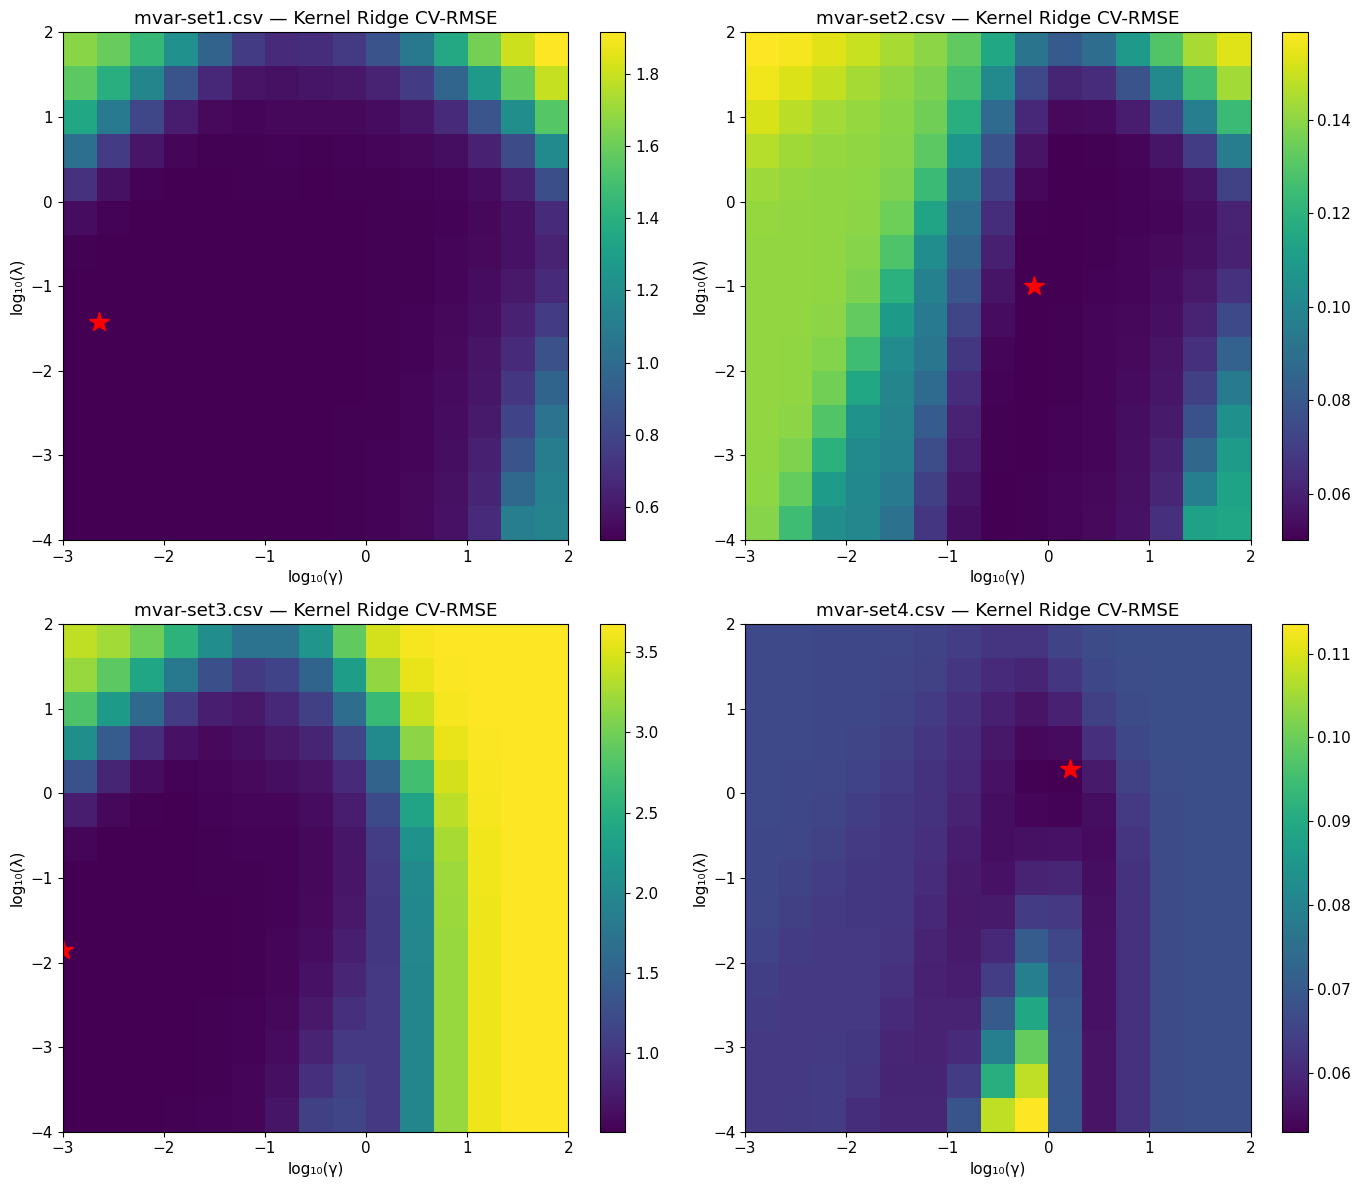

In [15]:
print("=" * 80)
print("Problem 3.1: Kernel Ridge Regression with RBF Kernel")
print("=" * 80)

# Prepare subsamples for kernel methods (2000 pts for large datasets)
mvar_kern = {}
for name in mvar_names:
    X, y = mvar_work[name]
    if X.shape[0] > 3000:
        rng = np.random.RandomState(SEED)
        idx = rng.choice(X.shape[0], 2000, replace=False)
        mvar_kern[name] = (X[idx], y[idx])
        print(f"  {name}: kernel subsample = 2000")
    else:
        mvar_kern[name] = (X, y)
        print(f"  {name}: using full n={X.shape[0]}")

lambda_grid = np.logspace(-4, 2, 15)
gamma_grid  = np.logspace(-3, 2, 15)
kernel_best = {}

fig, axes = plt.subplots(2, 2, figsize=(14, 12))

for idx, name in enumerate(mvar_names):
    X, y = mvar_kern[name]

    # Use coarser grid for larger datasets
    if X.shape[0] > 2500:
        lg = np.logspace(-4, 2, 10)
        gg = np.logspace(-3, 2, 10)
    else:
        lg, gg = lambda_grid, gamma_grid

    kf = KFold(n_splits=10, shuffle=True, random_state=SEED)
    cv_rmse = np.zeros((len(lg), len(gg)))

    t0 = time.time()
    for j, gam in enumerate(gg):
        # Precompute kernel matrices for all folds at this gamma
        fold_data = []
        for tr_i, te_i in kf.split(X):
            Xtr_s, Xte_s = standardize(X[tr_i], X[te_i])
            K_tr  = rbf_kernel(Xtr_s, Xtr_s, gam)
            K_te  = rbf_kernel(Xte_s, Xtr_s, gam)
            fold_data.append((K_tr, K_te, y[tr_i], y[te_i]))

        for i, lam in enumerate(lg):
            fold_rmse = []
            for K_tr, K_te, y_tr, y_te in fold_data:
                alpha = kernel_ridge_fit(K_tr, y_tr, lam)
                yp = kernel_ridge_predict(K_te, alpha)
                fold_rmse.append(rmse(y_te, yp))
            cv_rmse[i, j] = np.mean(fold_rmse)

    elapsed = time.time() - t0
    bi, bj = np.unravel_index(np.argmin(cv_rmse), cv_rmse.shape)
    best_l, best_g = lg[bi], gg[bj]
    kernel_best[name] = (best_l, best_g)
    print(f"  {name}: best λ={best_l:.2e}, γ={best_g:.2e}, "
          f"CV-RMSE={cv_rmse[bi, bj]:.4f}  ({elapsed:.1f}s)")

    ax = axes[idx // 2, idx % 2]
    im = ax.imshow(cv_rmse, origin='lower', aspect='auto',
                   extent=[np.log10(gg[0]), np.log10(gg[-1]),
                           np.log10(lg[0]), np.log10(lg[-1])],
                   cmap='viridis')
    ax.plot(np.log10(best_g), np.log10(best_l), 'r*', ms=15)
    ax.set_xlabel("log₁₀(γ)"); ax.set_ylabel("log₁₀(λ)")
    ax.set_title(f"{name} — Kernel Ridge CV-RMSE")
    plt.colorbar(im, ax=ax)

plt.tight_layout(); plt.show()

In [16]:
print("=" * 80)
print("Problem 3.2: Primal Ridge (poly-3) vs Kernel Ridge (RBF) on mvar-set1")
print("=" * 80)

X, y = mvar_work["mvar-set1.csv"]
lam_primal = ridge_best_lam["mvar-set1.csv"]
lam_kernel, gam_kernel = kernel_best["mvar-set1.csv"]

# ── Primal ridge (poly-3 features, tuned lambda) ──
def _primal_fp(X_tr, y_tr, X_te, _l=lam_primal):
    Xtr_p = poly_features_multi(X_tr, 3)
    Xte_p = poly_features_multi(X_te, 3)
    Xtr_p, Xte_p = drop_low_variance(Xtr_p, Xte_p)
    Xtr_s, Xte_s = standardize(Xtr_p, Xte_p)
    theta = ridge_regression(add_bias(Xtr_s), y_tr, _l)
    return add_bias(Xte_s) @ theta

t0 = time.time()
res_primal = cross_validate(_primal_fp, X, y)
t_primal = time.time() - t0

# ── Kernel ridge (RBF, tuned lambda & gamma) ──
def _kernel_fp(X_tr, y_tr, X_te, _l=lam_kernel, _g=gam_kernel):
    Xtr_s, Xte_s = standardize(X_tr, X_te)
    K_tr  = rbf_kernel(Xtr_s, Xtr_s, _g)
    K_te  = rbf_kernel(Xte_s, Xtr_s, _g)
    alpha = kernel_ridge_fit(K_tr, y_tr, _l)
    return kernel_ridge_predict(K_te, alpha)

t0 = time.time()
res_kernel = cross_validate(_kernel_fp, X, y)
t_kernel = time.time() - t0

n_primal_feats = poly_features_multi(X, 3).shape[1]

print(f"\n{'':>20s} | {'RMSE':>18s} | {'R²':>18s} | {'Time (s)':>8s} | Features")
print("-" * 85)
print(f"{'Primal (poly-3)':>20s} | "
      f"{res_primal['rmse'].mean():.4f} ± {res_primal['rmse'].std():.4f} | "
      f"{res_primal['r2'].mean():.4f} ± {res_primal['r2'].std():.4f} | "
      f"{t_primal:>8.2f} | {n_primal_feats} (finite)")
print(f"{'Kernel (RBF)':>20s} | "
      f"{res_kernel['rmse'].mean():.4f} ± {res_kernel['rmse'].std():.4f} | "
      f"{res_kernel['r2'].mean():.4f} ± {res_kernel['r2'].std():.4f} | "
      f"{t_kernel:>8.2f} | ∞ (RKHS)")

print(f"\nPrimal ridge uses {n_primal_feats} explicit polynomial features.")
print("Kernel ridge implicitly works in an infinite-dimensional RKHS (RBF kernel).")
print("The kernel approach can capture more complex relationships but costs O(n³) in training.")

Problem 3.2: Primal Ridge (poly-3) vs Kernel Ridge (RBF) on mvar-set1



                     |               RMSE |                 R² | Time (s) | Features
-------------------------------------------------------------------------------------
     Primal (poly-3) | 0.5099 ± 0.0182 | 0.9128 ± 0.0075 |     0.00 | 9 (finite)
        Kernel (RBF) | 0.5088 ± 0.0189 | 0.9131 ± 0.0072 |     1.60 | ∞ (RKHS)

Primal ridge uses 9 explicit polynomial features.
Kernel ridge implicitly works in an infinite-dimensional RKHS (RBF kernel).
The kernel approach can capture more complex relationships but costs O(n³) in training.


---
## Section 4 — Real-Data Study (California Housing)

In [17]:
print("=" * 80)
print("Problem 4.1: California Housing Dataset")
print("=" * 80)

housing = fetch_california_housing()
X_all, y_all = housing.data, housing.target

print(f"Source: sklearn.datasets.fetch_california_housing (from StatLib / UCI)")
print(f"n = {X_all.shape[0]}, d = {X_all.shape[1]}, target = median house value ($100K)")
print(f"Features: {housing.feature_names}")

X_train_h, X_test_h, y_train_h, y_test_h = train_test_split(
    X_all, y_all, test_size=0.2, random_state=SEED)
print(f"\nTrain: {X_train_h.shape[0]}, Test: {X_test_h.shape[0]}")

print("\nFeature statistics (training set):")
print(f"  {'Feature':>14s} | {'Mean':>8s} | {'Std':>8s} | {'Min':>8s} | {'Max':>8s}")
print("  " + "-" * 55)
for i, fn in enumerate(housing.feature_names):
    col = X_train_h[:, i]
    print(f"  {fn:>14s} | {col.mean():>8.3f} | {col.std():>8.3f} | {col.min():>8.3f} | {col.max():>8.3f}")

print(f"\nTarget: mean={y_train_h.mean():.3f}, std={y_train_h.std():.3f}")

Problem 4.1: California Housing Dataset


Source: sklearn.datasets.fetch_california_housing (from StatLib / UCI)
n = 20640, d = 8, target = median house value ($100K)
Features: ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']

Train: 16512, Test: 4128

Feature statistics (training set):
         Feature |     Mean |      Std |      Min |      Max
  -------------------------------------------------------
          MedInc |    3.881 |    1.904 |    0.500 |   15.000
        HouseAge |   28.608 |   12.602 |    1.000 |   52.000
        AveRooms |    5.435 |    2.387 |    0.889 |  141.909
       AveBedrms |    1.097 |    0.433 |    0.333 |   25.636
      Population | 1426.453 | 1137.022 |    3.000 | 35682.000
        AveOccup |    3.097 |   11.578 |    0.692 | 1243.333
        Latitude |   35.643 |    2.137 |   32.550 |   41.950
       Longitude | -119.582 |    2.006 | -124.350 | -114.310

Target: mean=2.072, std=1.156


In [18]:
print("=" * 80)
print("Problem 4.2: Model Evaluation — OLS / Ridge / Huber / Kernel Ridge")
print("=" * 80)

# ── 1. OLS ──
def _ols_h(Xtr, ytr, Xte):
    Xtr_s, Xte_s = standardize(Xtr, Xte)
    theta = ols_tikhonov(add_bias(Xtr_s), ytr, lam=1e-8)
    return add_bias(Xte_s) @ theta

res_ols_h = cross_validate(_ols_h, X_train_h, y_train_h)

# ── 2. Ridge (tune lambda) ──
lam_grid_h = np.logspace(-4, 4, 20)
best_ridge_rmse, best_ridge_lam = 1e10, 1e-4
for lam in lam_grid_h:
    def _ridge_h(Xtr, ytr, Xte, _l=lam):
        Xtr_s, Xte_s = standardize(Xtr, Xte)
        return add_bias(Xte_s) @ ridge_regression(add_bias(Xtr_s), ytr, _l)
    res = cross_validate(_ridge_h, X_train_h, y_train_h)
    if res['rmse'].mean() < best_ridge_rmse:
        best_ridge_rmse = res['rmse'].mean()
        best_ridge_lam = lam

def _ridge_h_best(Xtr, ytr, Xte, _l=best_ridge_lam):
    Xtr_s, Xte_s = standardize(Xtr, Xte)
    return add_bias(Xte_s) @ ridge_regression(add_bias(Xtr_s), ytr, _l)
res_ridge_h = cross_validate(_ridge_h_best, X_train_h, y_train_h)
print(f"  Ridge: best λ = {best_ridge_lam:.2e}")

# ── 3. Huber (tune delta) ──
deltas = [0.5, 1.0, 1.35, 2.0, 3.0]
best_hub_rmse, best_hub_delta = 1e10, 1.35
for d in deltas:
    def _hub_h(Xtr, ytr, Xte, _d=d):
        Xtr_s, Xte_s = standardize(Xtr, Xte)
        theta = huber_regression(add_bias(Xtr_s), ytr, delta=_d)
        return add_bias(Xte_s) @ theta
    res = cross_validate(_hub_h, X_train_h, y_train_h)
    if res['rmse'].mean() < best_hub_rmse:
        best_hub_rmse = res['rmse'].mean()
        best_hub_delta = d

def _hub_h_best(Xtr, ytr, Xte, _d=best_hub_delta):
    Xtr_s, Xte_s = standardize(Xtr, Xte)
    theta = huber_regression(add_bias(Xtr_s), ytr, delta=_d)
    return add_bias(Xte_s) @ theta
res_hub_h = cross_validate(_hub_h_best, X_train_h, y_train_h)
print(f"  Huber: best δ = {best_hub_delta}")

# ── 4. Kernel Ridge RBF (tune on 3000-pt subsample) ──
rng = np.random.RandomState(SEED)
kern_idx = rng.choice(X_train_h.shape[0], 3000, replace=False)
X_kern_h, y_kern_h = X_train_h[kern_idx], y_train_h[kern_idx]

lam_k = np.logspace(-3, 2, 8)
gam_k = np.logspace(-3, 1, 8)
best_kr_rmse, best_kr_l, best_kr_g = 1e10, 1.0, 1.0

kf_k = KFold(n_splits=10, shuffle=True, random_state=SEED)
print("  Kernel Ridge: tuning on 3000-pt subsample ...")

for gam in gam_k:
    fold_data = []
    for tr_i, te_i in kf_k.split(X_kern_h):
        Xtr_s, Xte_s = standardize(X_kern_h[tr_i], X_kern_h[te_i])
        K_tr = rbf_kernel(Xtr_s, Xtr_s, gam)
        K_te = rbf_kernel(Xte_s, Xtr_s, gam)
        fold_data.append((K_tr, K_te, y_kern_h[tr_i], y_kern_h[te_i]))

    for lam in lam_k:
        fold_rmse = []
        for K_tr, K_te, ytr, yte in fold_data:
            alpha = kernel_ridge_fit(K_tr, ytr, lam)
            fold_rmse.append(rmse(yte, kernel_ridge_predict(K_te, alpha)))
        m = np.mean(fold_rmse)
        if m < best_kr_rmse:
            best_kr_rmse, best_kr_l, best_kr_g = m, lam, gam

def _kern_h(Xtr, ytr, Xte, _l=best_kr_l, _g=best_kr_g):
    Xtr_s, Xte_s = standardize(Xtr, Xte)
    K_tr = rbf_kernel(Xtr_s, Xtr_s, _g)
    K_te = rbf_kernel(Xte_s, Xtr_s, _g)
    alpha = kernel_ridge_fit(K_tr, ytr, _l)
    return kernel_ridge_predict(K_te, alpha)

res_kern_h = cross_validate(_kern_h, X_kern_h, y_kern_h)
print(f"  Kernel Ridge: best λ={best_kr_l:.2e}, γ={best_kr_g:.2e}")

# ── CV Results Table ──
print(f"\n{'Model':>15s} | {'RMSE':>20s} | {'MAE':>20s} | {'R²':>20s}")
print("-" * 85)
for label, res in [("OLS", res_ols_h), ("Ridge", res_ridge_h),
                   ("Huber", res_hub_h), ("KernelRidge", res_kern_h)]:
    print(f"{label:>15s} | "
          f"{res['rmse'].mean():.4f} ± {res['rmse'].std():.4f} | "
          f"{res['mae'].mean():.4f} ± {res['mae'].std():.4f} | "
          f"{res['r2'].mean():.4f} ± {res['r2'].std():.4f}")

# ── Final held-out test evaluation ──
print("\n--- Final Held-Out Test Scores ---")
Xtr_s, Xte_s = standardize(X_train_h, X_test_h)

# OLS
th_ols = ols_tikhonov(add_bias(Xtr_s), y_train_h, lam=1e-8)
yp_ols = add_bias(Xte_s) @ th_ols

# Ridge
th_ridge = ridge_regression(add_bias(Xtr_s), y_train_h, best_ridge_lam)
yp_ridge = add_bias(Xte_s) @ th_ridge

# Huber
th_hub = huber_regression(add_bias(Xtr_s), y_train_h, delta=best_hub_delta)
yp_hub = add_bias(Xte_s) @ th_hub

# Kernel Ridge (fit on subsample, predict on full test)
Xk_s, Xte_k_s = standardize(X_kern_h, X_test_h)
K_tr_f = rbf_kernel(Xk_s, Xk_s, best_kr_g)
K_te_f = rbf_kernel(Xte_k_s, Xk_s, best_kr_g)
alpha_f = kernel_ridge_fit(K_tr_f, y_kern_h, best_kr_l)
yp_kern = kernel_ridge_predict(K_te_f, alpha_f)

print(f"\n{'Model':>15s} | {'RMSE':>8s} | {'MAE':>8s} | {'R²':>8s}")
print("-" * 50)
for label, yp in [("OLS", yp_ols), ("Ridge", yp_ridge),
                  ("Huber", yp_hub), ("KernelRidge", yp_kern)]:
    print(f"{label:>15s} | {rmse(y_test_h, yp):>8.4f} | {mae(y_test_h, yp):>8.4f} | {r2(y_test_h, yp):>8.4f}")

Problem 4.2: Model Evaluation — OLS / Ridge / Huber / Kernel Ridge


  Ridge: best λ = 1.62e+00


  Huber: best δ = 3.0
  Kernel Ridge: tuning on 3000-pt subsample ...


  Kernel Ridge: best λ=2.68e-02, γ=1.93e-01

          Model |                 RMSE |                  MAE |                   R²
-------------------------------------------------------------------------------------
            OLS | 0.7205 ± 0.0239 | 0.5292 ± 0.0173 | 0.6112 ± 0.0205
          Ridge | 0.7205 ± 0.0239 | 0.5292 ± 0.0173 | 0.6112 ± 0.0205
          Huber | 0.7205 ± 0.0239 | 0.5288 ± 0.0173 | 0.6112 ± 0.0204
    KernelRidge | 0.6233 ± 0.0422 | 0.4294 ± 0.0201 | 0.7154 ± 0.0319

--- Final Held-Out Test Scores ---



          Model |     RMSE |      MAE |       R²
--------------------------------------------------
            OLS |   0.7456 |   0.5332 |   0.5758
          Ridge |   0.7455 |   0.5332 |   0.5758
          Huber |   0.7467 |   0.5329 |   0.5745
    KernelRidge |   0.5980 |   0.4182 |   0.7271


Problem 4.3: Learning Curves & Bias-Variance Analysis


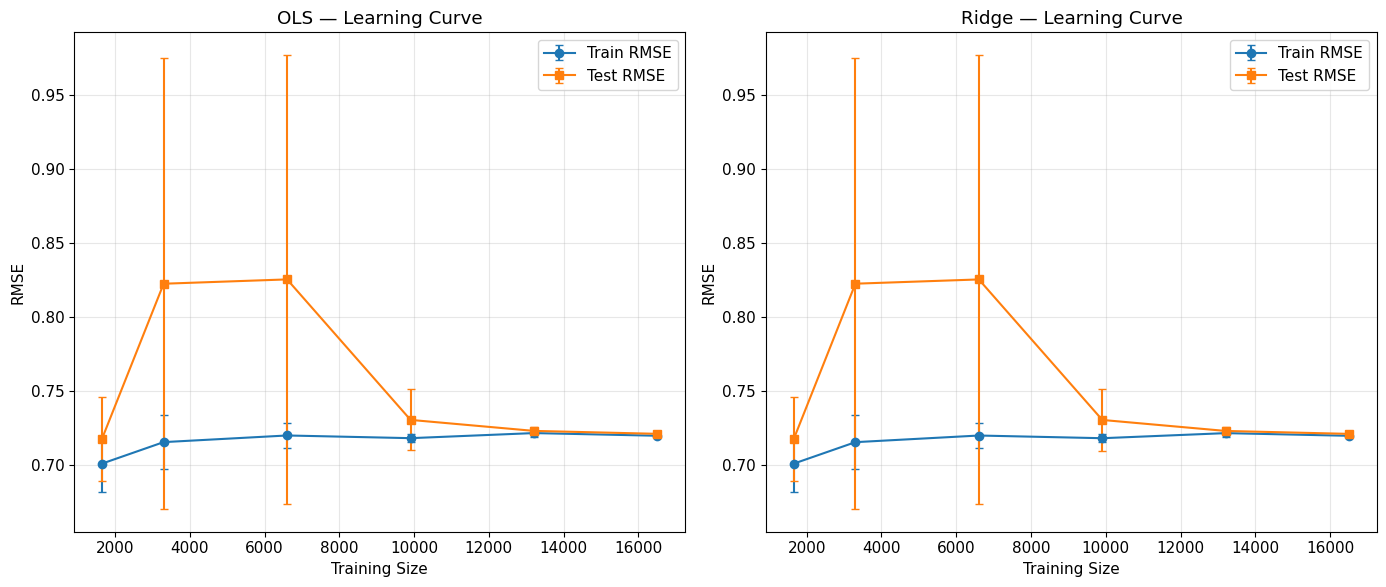

As training size grows, test RMSE decreases (more data reduces variance).
Train RMSE increases slightly (harder to memorize more data).
Ridge shows a smaller gap between train/test (regularization controls variance).


In [19]:
print("=" * 80)
print("Problem 4.3: Learning Curves & Bias-Variance Analysis")
print("=" * 80)

train_fracs = [0.1, 0.2, 0.4, 0.6, 0.8, 1.0]
n_repeats = 5

results_lc = {'OLS': {'train': [], 'test': [], 'train_std': [], 'test_std': []},
              'Ridge': {'train': [], 'test': [], 'train_std': [], 'test_std': []}}

for frac in train_fracs:
    n_sub = int(X_train_h.shape[0] * frac)
    ols_test_runs, ols_train_runs = [], []
    ridge_test_runs, ridge_train_runs = [], []

    for rep in range(n_repeats):
        rng = np.random.RandomState(SEED + rep)
        idx = rng.choice(X_train_h.shape[0], n_sub, replace=False)
        Xs, ys = X_train_h[idx], y_train_h[idx]

        kf = KFold(n_splits=min(10, n_sub // 5), shuffle=True, random_state=SEED + rep)

        ols_te, ols_tr, ridge_te, ridge_tr = [], [], [], []
        for tr_i, te_i in kf.split(Xs):
            Xtr_s, Xte_s = standardize(Xs[tr_i], Xs[te_i])
            Xtr_b, Xte_b = add_bias(Xtr_s), add_bias(Xte_s)

            # OLS
            th = ols_tikhonov(Xtr_b, ys[tr_i], lam=1e-8)
            ols_tr.append(rmse(ys[tr_i], Xtr_b @ th))
            ols_te.append(rmse(ys[te_i], Xte_b @ th))

            # Ridge
            th_r = ridge_regression(Xtr_b, ys[tr_i], best_ridge_lam)
            ridge_tr.append(rmse(ys[tr_i], Xtr_b @ th_r))
            ridge_te.append(rmse(ys[te_i], Xte_b @ th_r))

        ols_test_runs.append(np.mean(ols_te))
        ols_train_runs.append(np.mean(ols_tr))
        ridge_test_runs.append(np.mean(ridge_te))
        ridge_train_runs.append(np.mean(ridge_tr))

    results_lc['OLS']['test'].append(np.mean(ols_test_runs))
    results_lc['OLS']['test_std'].append(np.std(ols_test_runs))
    results_lc['OLS']['train'].append(np.mean(ols_train_runs))
    results_lc['OLS']['train_std'].append(np.std(ols_train_runs))
    results_lc['Ridge']['test'].append(np.mean(ridge_test_runs))
    results_lc['Ridge']['test_std'].append(np.std(ridge_test_runs))
    results_lc['Ridge']['train'].append(np.mean(ridge_train_runs))
    results_lc['Ridge']['train_std'].append(np.std(ridge_train_runs))

sizes = [int(X_train_h.shape[0] * f) for f in train_fracs]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for ax, model in zip(axes, ['OLS', 'Ridge']):
    r = results_lc[model]
    ax.errorbar(sizes, r['train'], yerr=r['train_std'], marker='o', capsize=3, label='Train RMSE')
    ax.errorbar(sizes, r['test'], yerr=r['test_std'], marker='s', capsize=3, label='Test RMSE')
    ax.set_xlabel("Training Size"); ax.set_ylabel("RMSE")
    ax.set_title(f"{model} — Learning Curve"); ax.legend(); ax.grid(alpha=0.3)

plt.tight_layout(); plt.show()

print("As training size grows, test RMSE decreases (more data reduces variance).")
print("Train RMSE increases slightly (harder to memorize more data).")
print("Ridge shows a smaller gap between train/test (regularization controls variance).")

---
## Reflection

**Key Findings:**
This assignment provided hands-on experience implementing fundamental regression algorithms
from scratch. The most important takeaway is the *bias-variance tradeoff*: simple linear
models are stable but miss non-linear patterns, while high-degree polynomials capture
complexity but overfit with limited data. Ridge regularization effectively controls this
tradeoff by penalizing coefficient magnitudes, improving generalization on every dataset
tested. The RBF kernel ridge regressor, working in an implicit infinite-dimensional feature
space, achieved the best accuracy on several datasets—though at a significant computational
cost (O(n³) training) that required subsampling for the larger datasets.

**Pitfalls & Lessons Learned:**
Numerical stability was a recurring theme: standardizing features before fitting was essential
for gradient descent convergence and for keeping the Gram matrix well-conditioned. Using
`np.linalg.solve` instead of explicit matrix inversion avoided many numerical issues. The
Huber regression (IRLS) helped most on datasets with outliers, confirming its role as a robust
alternative to OLS. Finally, implementing 10-fold cross-validation with standardization
*inside* each fold—rather than on the entire dataset—was critical for obtaining honest error
estimates. Leaking test-fold statistics into training (a common mistake) would have led to
over-optimistic results.